## Import The Library

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


## Load Dataset

In [2]:
df = pd.read_csv('D:\AI Health Prediction\diabetes-prediction-master\data\diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Basic Analysis

**Shape of the Dataset**

In [3]:
df.shape

(768, 9)

**Getting the stastical summary of the Data**

In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Diabetics and Non-Diabetics**

In [5]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## Data Cleaning

### Check Null Values

In [6]:

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Check For Missing Values 

In [8]:

print('No of missing values in Glucose: ', df[df['Glucose'] == 0].shape[0])
print('No of missing values in BloodPressure: ', df[df['BloodPressure'] == 0].shape[0])
print('No of missing values in SkinThickness: ', df[df['SkinThickness'] == 0].shape[0])
print('No of missing values in Insulin: ', df[df['Insulin'] == 0].shape[0])
print('No of missing values in BMI: ', df[df['BMI'] == 0].shape[0])

No of missing values in Glucose:  5
No of missing values in BloodPressure:  35
No of missing values in SkinThickness:  227
No of missing values in Insulin:  374
No of missing values in BMI:  11


### Replace missing values with mean

In [9]:

df['Glucose'] = df['Glucose'].replace(0, df['Glucose'].mean())
df['BloodPressure'] = df['BloodPressure'].replace(0, df['BloodPressure'].mean())
df['SkinThickness'] = df['SkinThickness'].replace(0, df['SkinThickness'].mean())
df['Insulin'] = df['Insulin'].replace(0, df['Insulin'].mean())
df['BMI'] = df['BMI'].replace(0, df['BMI'].mean())

### Check for Duplicates 

In [7]:
df.duplicated()  ## No duplicates are available

0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Length: 768, dtype: bool

## Data Visualisation

### Count plot

Text(0, 0.5, '')

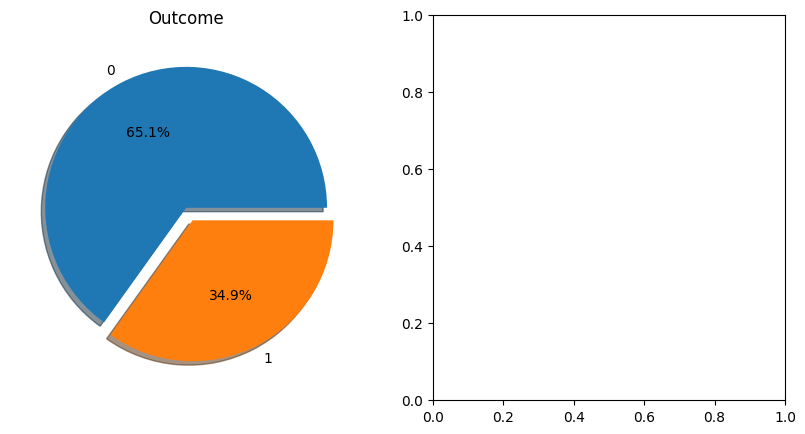

In [10]:
import matplotlib.pyplot as plt
f, ax = plt.subplots(1,2,figsize=(10,5))
df['Outcome'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%', ax=ax[0],shadow=True)
ax[0].set_title('Outcome')
ax[0].set_ylabel('')


Negative(0) -> 500
Positive(1) -> 268


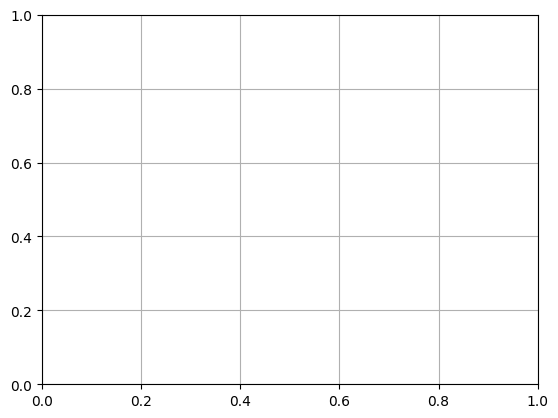

In [14]:
import seaborn as sns

sns.countplot(x='Outcome', data=df, ax=ax[1])

ax[1].set_title('Outcome')

N, P = df['Outcome'].value_counts()

print('Negative(0) ->', N)
print('Positive(1) ->', P)

plt.grid()
plt.show()

### Histogram (data is balanced or skewed)

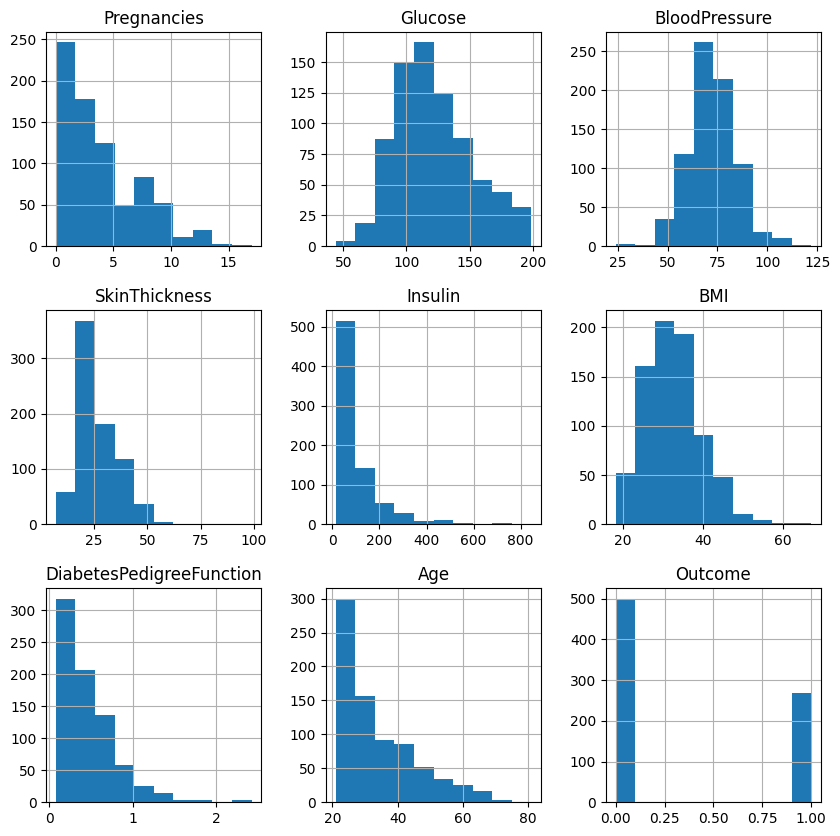

In [15]:

df.hist(bins=10,figsize=(10,10))
plt.show()

## Analysing relationships bw variables 

### Correlation analysis

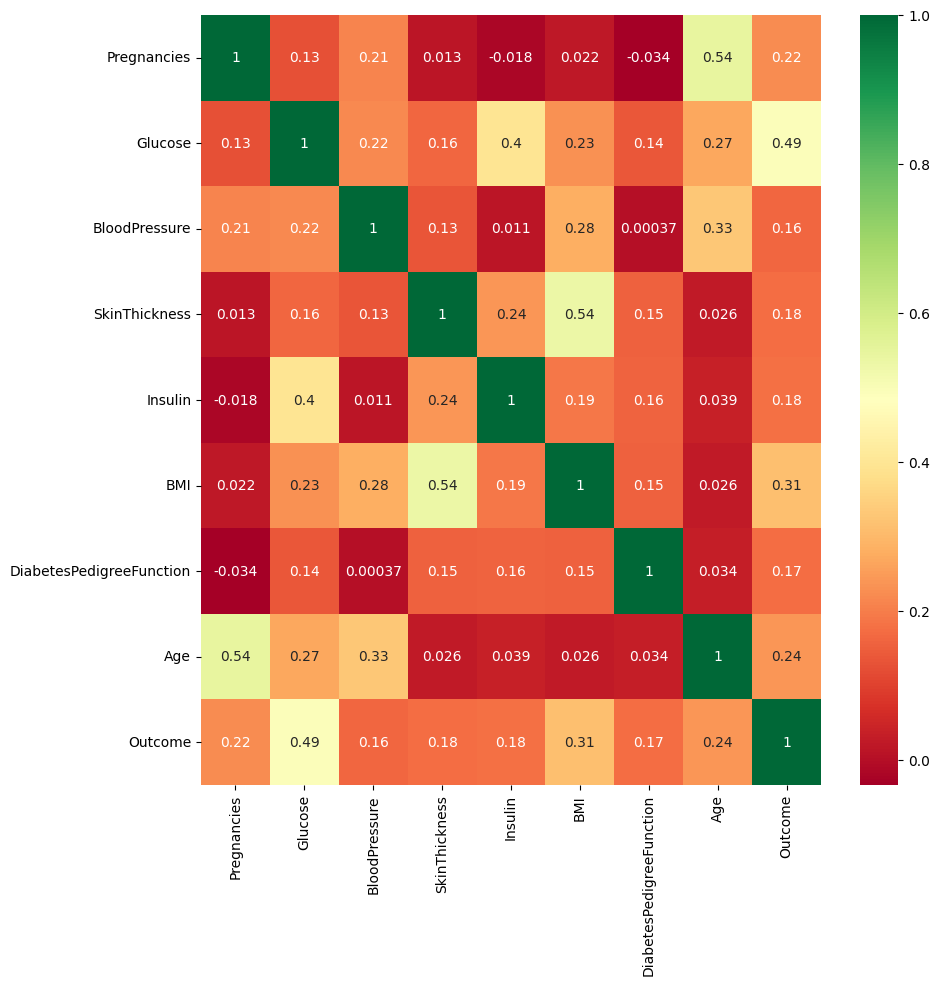

In [17]:
#get correlations of each feature in the dataset
corr_mat = df.corr()
top_corr_features = corr_mat.index
plt.figure(figsize=(10,10))

#plot heat map
g = sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='RdYlGn')

# ML Pipeline

### Split data into X and y

In [18]:
#separating the independent and dependent variables
X = df.drop(columns='Outcome', axis=1)
y = df['Outcome']
print(X.head())
print(y.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0            6    148.0           72.0      35.000000   79.799479  33.6   
1            1     85.0           66.0      29.000000   79.799479  26.6   
2            8    183.0           64.0      20.536458   79.799479  23.3   
3            1     89.0           66.0      23.000000   94.000000  28.1   
4            0    137.0           40.0      35.000000  168.000000  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


### Data Standardisation - Feature Scaling

In [19]:
scaler = StandardScaler()
scaler.fit(X)
standardised_data = scaler.transform(X)
print(standardised_data)

X = standardised_data
y = df.Outcome
print(X)
print(y)

[[ 0.63994726  0.86527574 -0.0210444  ...  0.16725546  0.46849198
   1.4259954 ]
 [-0.84488505 -1.20598931 -0.51658286 ... -0.85153454 -0.36506078
  -0.19067191]
 [ 1.23388019  2.01597855 -0.68176235 ... -1.33182125  0.60439732
  -0.10558415]
 ...
 [ 0.3429808  -0.02240928 -0.0210444  ... -0.90975111 -0.68519336
  -0.27575966]
 [-0.84488505  0.14197684 -1.01212132 ... -0.34213954 -0.37110101
   1.17073215]
 [-0.84488505 -0.94297153 -0.18622389 ... -0.29847711 -0.47378505
  -0.87137393]]
[[ 0.63994726  0.86527574 -0.0210444  ...  0.16725546  0.46849198
   1.4259954 ]
 [-0.84488505 -1.20598931 -0.51658286 ... -0.85153454 -0.36506078
  -0.19067191]
 [ 1.23388019  2.01597855 -0.68176235 ... -1.33182125  0.60439732
  -0.10558415]
 ...
 [ 0.3429808  -0.02240928 -0.0210444  ... -0.90975111 -0.68519336
  -0.27575966]
 [-0.84488505  0.14197684 -1.01212132 ... -0.34213954 -0.37110101
   1.17073215]
 [-0.84488505 -0.94297153 -0.18622389 ... -0.29847711 -0.47378505
  -0.87137393]]
0      1
1      

### Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

print(X.shape, X_train.shape, X_test.shape)


(768, 8) (614, 8) (154, 8)


## Classification Models

### Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(solver='liblinear', multi_class='ovr')
lr_model.fit(X_train, y_train)

c:\Users\agraw\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'ovr'


### K Neighbours Classifier

In [23]:

from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Naive Bayes Classifier

In [24]:

from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


### Support Vector Machine(SVM)

In [25]:
from sklearn.svm import SVC
svm_model = SVC()
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Decision tree

In [26]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


###  Random Forest

In [27]:

from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(criterion='entropy')
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Predicting & Evaluating the Models

In [28]:
lr_preds = lr_model.predict(X_test)

knn_preds = knn_model.predict(X_test)

nb_preds = nb_model.predict(X_test)

svm_preds = svm_model.predict(X_test)

dt_preds = dt_model.predict(X_test)

rf_preds = rf_model.predict(X_test)

In [29]:
#get the accuracy of the models
print('Accuracy score of Logistic Regression:', round(accuracy_score(y_test, lr_preds) * 100, 2))
print('Accuracy score of KNN:', round(accuracy_score(y_test, knn_preds) * 100, 2))
print('Accuracy score of Naive Bayes:', round(accuracy_score(y_test, nb_preds) * 100, 2))
print('Accuracy score of SVM:', round(accuracy_score(y_test, svm_preds) * 100, 2))
print('Accuracy score of Decision Tree:', round(accuracy_score(y_test, dt_preds) * 100, 2))
print('Accuracy score of Random Forest:', round(accuracy_score(y_test, rf_preds) * 100, 2))


Accuracy score of Logistic Regression: 77.27
Accuracy score of KNN: 74.68
Accuracy score of Naive Bayes: 74.03
Accuracy score of SVM: 83.12
Accuracy score of Decision Tree: 80.52
Accuracy score of Random Forest: 80.52


## Save the Model with the Highest Accuracy using pickle

In [32]:

import pickle
pickle.dump(svm_model, open('diabities_model.pkl', 'wb')) #svm has the highest accuracy

pickle.dump(scaler, open('diabities_scaler.pkl', 'wb')) #save the std scaler too